# Notebook 01 - Data Exploration

Goal:
Understand the structure of the EPL dataset and define the preficiton problem.

Note:
This is an explanatory model, not a true prediction. This works with post-match stats

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/EPL 13-14.csv")

In [ ]:
df.shape

(380, 68)

In [11]:
df.columns

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC',
       'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD',
       'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA',
       'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'Bb1X2',
       'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU',
       'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh',
       'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 68 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       380 non-null    object 
 1   Date      380 non-null    object 
 2   HomeTeam  380 non-null    object 
 3   AwayTeam  380 non-null    object 
 4   FTHG      380 non-null    int64  
 5   FTAG      380 non-null    int64  
 6   FTR       380 non-null    object 
 7   HTHG      380 non-null    int64  
 8   HTAG      380 non-null    int64  
 9   HTR       380 non-null    object 
 10  Referee   380 non-null    object 
 11  HS        380 non-null    int64  
 12  AS        380 non-null    int64  
 13  HST       380 non-null    int64  
 14  AST       380 non-null    int64  
 15  HF        380 non-null    int64  
 16  AF        380 non-null    int64  
 17  HC        380 non-null    int64  
 18  AC        380 non-null    int64  
 19  HY        380 non-null    int64  
 20  AY        380 non-null    int64 

In [13]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,...,380.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,380.000000,380.000000,380.000000
mean,1.573684,1.194737,0.700000,0.518421,14.955263,11.923684,5.036842,3.886842,10.494737,11.036842,...,2.005342,21.878378,-0.342568,1.996892,1.933811,2.005459,1.938946,2.865000,4.288553,5.333211
std,1.377291,1.202010,0.898254,0.717058,5.719069,4.957015,2.647986,2.146442,3.174349,3.412488,...,0.330928,3.098880,0.881367,0.174623,0.162637,0.174130,0.159943,1.878356,1.436841,4.636256
min,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,2.000000,3.000000,...,1.490000,16.000000,-2.500000,1.640000,1.590000,1.630000,1.580000,1.100000,3.020000,1.290000
25%,0.750000,0.000000,0.000000,0.000000,11.000000,8.000000,3.000000,2.000000,8.000000,9.000000,...,1.780000,19.000000,-1.000000,1.870000,1.820000,1.872500,1.812500,1.607500,3.407500,2.365000
50%,1.000000,1.000000,0.000000,0.000000,14.000000,12.000000,5.000000,4.000000,11.000000,11.000000,...,1.940000,22.000000,-0.375000,1.970000,1.910000,2.010000,1.950000,2.250000,3.695000,3.595000
75%,2.000000,2.000000,1.000000,1.000000,18.000000,15.000000,6.000000,5.000000,13.000000,13.000000,...,2.132500,24.000000,0.250000,2.120000,2.050000,2.120000,2.050000,3.310000,4.460000,6.245000
max,7.000000,6.000000,4.000000,3.000000,39.000000,29.000000,15.000000,12.000000,18.000000,24.000000,...,3.550000,29.000000,1.500000,2.540000,2.430000,2.500000,2.400000,13.500000,12.380000,30.000000


In [34]:
df['result'] = df['FTR'].map({'H':1,'D':0,'A':-1})
df['result'].value_counts()

result
 1    179
-1    123
 0     78
Name: count, dtype: int64

In [38]:
df[['result','FTHG','FTAG','HS','AS','HST','AST','HF','AF','HC','AC']].corr()

,result,FTHG,FTAG,HS,AS,HST,AST,HF,AF,HC,AC
result,1.000000,0.617722,-0.675465,0.208310,-0.288837,0.390407,-0.498004,0.002167,0.035953,0.084660,-0.060917
FTHG,0.617722,1.000000,-0.102723,0.272920,-0.163230,0.568623,-0.168981,-0.072935,-0.020789,0.076284,-0.116591
FTAG,-0.675465,-0.102723,1.000000,-0.160701,0.327978,-0.170540,0.626253,0.010642,-0.031987,-0.114447,0.060450
HS,0.208310,0.272920,-0.160701,1.000000,-0.442953,0.675942,-0.311646,-0.107346,-0.069001,0.495672,-0.282649
AS,-0.288837,-0.163230,0.327978,-0.442953,1.000000,-0.324422,0.644685,0.033762,-0.156749,-0.348807,0.538223
HST,0.390407,0.568623,-0.170540,0.675942,-0.324422,1.000000,-0.243910,-0.085357,-0.030810,0.293315,-0.178537
AST,-0.498004,-0.168981,0.626253,-0.311646,0.644685,-0.243910,1.000000,-0.009575,-0.120104,-0.227681,0.195846
HF,0.002167,-0.072935,0.010642,-0.107346,0.033762,-0.085357,-0.009575,1.000000,0.152740,-0.155216,0.000725
AF,0.035953,-0.020789,-0.031987,-0.069001,-0.156749,-0.030810,-0.120104,0.152740,1.000000,-0.087148,-0.075075
HC,0.084660,0.076284,-0.114447,0.495672,-0.348807,0.293315,-0.227681,-0.155216,-0.087148,1.000000,-0.233232


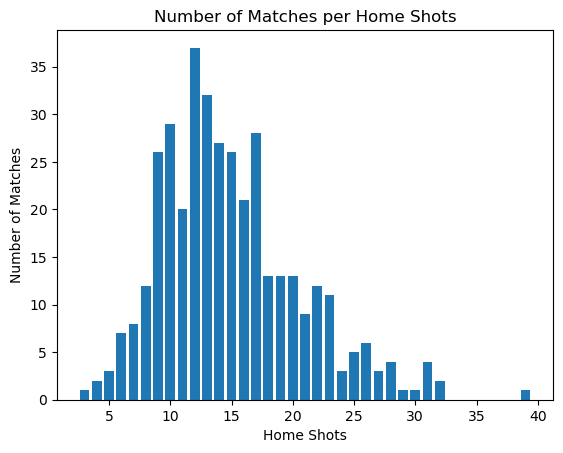

In [26]:
counts = df['HS'].value_counts().sort_index()

plt.bar(counts.index, counts.values)
plt.xlabel("Home Shots")
plt.ylabel("Number of Matches")
plt.title("Number of Matches per Home Shots")
plt.show()

<Axes: >

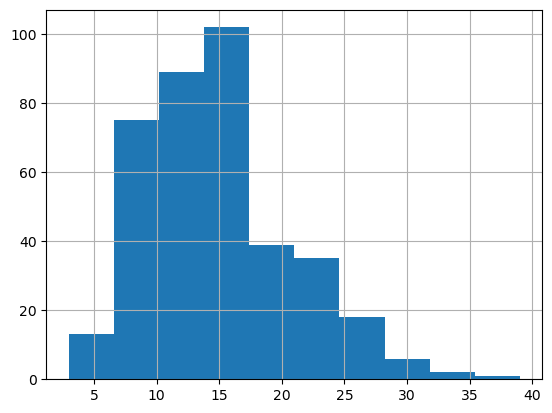

In [27]:
df['HS'].hist()

In [35]:
df.corr(numeric_only=True)['result'].sort_values(ascending=False)

result    1.000000
FTHG      0.617722
HTHG      0.453100
BWA       0.404479
BbAvA     0.393021
            ...   
IWH      -0.405102
HTAG     -0.430635
BbAHh    -0.447481
AST      -0.498004
FTAG     -0.675465
Name: result, Length: 62, dtype: float64